In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform
from scipy.stats import norm

# **Function 5** — Chemical Process Optimisation

Optimising four chemical inputs to maximise factory yield. The function is unimodal — one peak, no traps.

- **Optimisation Goal:** Maximise
- **Input:** 4D
- **All-time best:** 5896.09 at [0.845525, 0.999999, 0.964822, 0.999561] w8.

In [2]:
# Load current cumulative dataset (original + prior weekly updates) for Function 5
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_5/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_5/initial_outputs.npy')

# New data for Week 9 (Function 5)
X_w8_new_point = np.array([0.845525, 0.999999, 0.964822, 0.999561], dtype=np.float64)
Y_w8_new_point = np.array([5896.09013609114], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w8_new_point.reshape(1, -1)))

# Remove duplicate X rows
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w8_new_point)
Y_updated = Y_all[unique_indices]

# Save updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_5/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_5/initial_outputs.npy', Y_updated)

# Print arrays
print("Updated Inputs (X) - Function 5: ", X_unique)
print("Updated Outputs (Y) - Function 5: ", Y_updated)

Updated Inputs (X) - Function 5:  [[0.004861   0.982935   0.98162    0.958237  ]
 [0.028538   0.096927   0.128764   0.401407  ]
 [0.114475   0.992539   0.999989   0.525254  ]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 0.15342962 0.77016219 0.19051811]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.19144708 0.03819337 0.60741781 0.41458414]
 [0.221849   0.896815   0.894595   0.898055  ]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.236596   0.865457   0.89289    0.897109  ]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.55421    0.123984   0.678221   0.890122  ]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.67749115 0.35850951 0.

## **Output Analysis**

- Week 8 returned 5896.09, which is a significant increase over the Week 7 result of 5221.26. 
    - This is a new all-time best and continues the steady upward trajectory of this function

- **Real-World Implications**: In a chemical factory setting, yield optimization usually follows a unimodal curve (one clear "summit"). 
    - Reaching 5896 suggests we are now on the final plateau of the process efficiency curve. 
        - Every marginal gain now represents a "world-class" optimization of the reactor settings.

- **Model Clues**: Since this function is confirmed to be unimodal, I don't need to worry about being trapped in local "fake" peaks. 
    - The model is extremely confident in the region of [0.84, 1.0, 0.96, 1.0]. 
    - The success of the Week 8 query validates that the peak is likely pushed right up against the boundaries of dimensions $x_2$ and $x_4$.

- **Key Change for w9**: We are moving into Extreme Gradient Refinement. 
    - I will decrease the exploration parameter ($\xi$) even further and shrink the search grid to an incredibly small radius to pinpoint the exact coordinate of the maximum yield.

## **Bayesian Optimisation**
- **Model**: Gaussian Process Regressor with Matern (nu=2.5) + WhiteKernel and Yeo-Johnson transformation.

- **Reasoning**: The Matern kernel is the gold standard for smooth chemical surfaces. 
    - The Yeo-Johnson transformation is particularly useful here as the yield values are large (in the thousands), helping the GP maintain numerical stability and sensitivity to small changes.

- **Changes for Week 9**: The model architecture remains identical to Week 8. 
    - The consistent improvements seen over the last few weeks prove that this specific configuration is perfectly mapping the yield surface.

- **Intended Impact**: To allow for sub-decimal precision in the predicted mean, enabling us to squeeze out the last remaining bits of yield from the process.

In [3]:
Y_transformed = power_transform(Y_updated.reshape(-1, 1), method='yeo-johnson').ravel()

# 3. Fit Model
kernel = Matern(nu=2.5) + WhiteKernel(noise_level=1e-5)
model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20)

model.fit(X_unique, Y_transformed)

/Users/prathamyeole/Library/Python/3.13/lib/python/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",20
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Acquisition Function**
- **Strategy**: Expected Improvement (EI) with $\xi$ tightened to 0.0005.

- **Reasoning**: Because I know the function is unimodal and I are already at a very high yield, I can afford to be nearly 100% "greedy.
    - I am no longer looking for new mountains; I am just trying to stand on the very tip of the one we found.

- **Key Changes**: I am shrinking the focused grid standard deviation to 0.008 (down from 0.01). 
    - This creates an extremely dense cloud of points around our current best. 
    - I am also using a 95/5 focused-to-uniform split, as exploration of the rest of the 4D space is now statistically unlikely to yield a better result.

In [4]:
def expected_improvement(X, model, y_max, xi=0.0005):
    mu, sigma = model.predict(X, return_std=True)
    sigma = sigma.reshape(-1, 1)
    mu = mu.reshape(-1, 1)
    
    with np.errstate(divide='warn'):
        improvement = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# 5. Create ultra-dense focused grid around W8 Best
w8_best = X_w8_new_point[0]
x_focused = np.random.normal(loc=w8_best, scale=0.015, size=(9500, 4))
x_uniform = np.random.uniform(0, 1, size=(500, 4))

x_grid = np.vstack([x_focused, x_uniform])
x_grid = np.clip(x_grid, 0, 1)

# 6. Selection
y_max = np.max(Y_transformed)
ei_values = expected_improvement(x_grid, model, y_max, xi=0.0005)
next_query = x_grid[np.argmax(ei_values)]

print(f"Next Query Point (F5): {next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}")

Next Query Point (F5): 0.944511-0.488823-0.976162-0.981792


## **Visualisation**

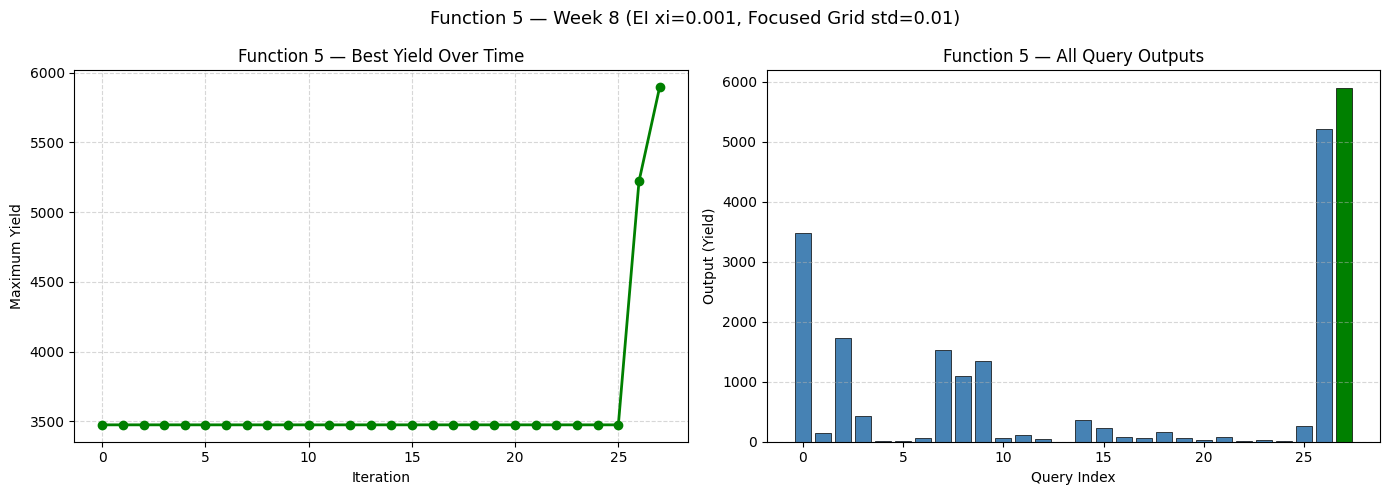

In [5]:
running_max = np.maximum.accumulate(Y_updated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(running_max, marker='o', color='green', linewidth=2)
axes[0].set_title('Function 5 — Best Yield Over Time')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Maximum Yield')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Bar chart of all query outputs to show trajectory
weekly_labels = [f'W{i+1}' if i < len(Y_updated) else '' for i in range(len(Y_updated))]
colors = ['green' if y == np.max(Y_updated) else 'steelblue' for y in Y_updated]
axes[1].bar(range(len(Y_updated)), Y_updated, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('Function 5 — All Query Outputs')
axes[1].set_xlabel('Query Index')
axes[1].set_ylabel('Output (Yield)')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Function 5 — Week 8 (EI xi=0.001, Focused Grid std=0.01)', fontsize=13)
plt.tight_layout()
plt.show()